# Wafer Anomaly Detection with PatchCore (50k Train Normals)

### Improvements vs baseline
| Change | Detail |
|---|---|
| **Backbone** | ResNet18 → WideResNet-50-2 |
| **Layers** | layer2+3 → layer2+3+4 (3584-dim) |
| **Memory bank** | Random sampling → PCA(128) + random coreset (fast, <2 min) |
| **nn_k scorer** | Was defaulting to 1 → consistently 3 everywhere |
| **topk_ratio** | 5% → 2% |

Pipeline:
1. Load and clean WM-811K style wafer data
2. Convert wafer maps to 3-channel tensors
3. Extract multi-scale patch embeddings from WideResNet-50-2 (layers 2+3+4)
4. PCA compress to 128-dim, then build memory bank with random coreset
5. Score test images by k-NN (k=3) patch distance
6. Evaluate with ROC-AUC, confusion matrix, and classification report

In [1]:
# Core imports
import os
import gc
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchvision.models import wide_resnet50_2, Wide_ResNet50_2_Weights
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

print('Using device:', DEVICE)

Using device: cuda


In [2]:
# Configuration
DATA_PATH  = '../data/raw/LSWMD.pkl'
IMAGE_SIZE = 224

NUM_WORKERS        = 0
PIN_MEMORY         = False
PERSISTENT_WORKERS = False
PREFETCH_FACTOR    = None
BATCH_SIZE         = 64 if USE_CUDA else 32

TRAIN_NORMAL_N = 20000
TUNE_NORMAL_N  = 2500
TUNE_DEFECT_N  = 2500
TEST_NORMAL_N  = 5000
TEST_DEFECT_N  = 2500

# --- Memory bank ---
# PCA compresses 3584-dim -> PCA_DIM before any distance/coreset work.
# This is the single biggest speed lever: kNN at 128-dim is ~28x faster than 3584-dim.
PCA_DIM                 = 128    # retains >95% variance in practice
CORESET_CANDIDATES      = 240000 if USE_CUDA else 80000   # random pre-sample
MEMORY_BANK_MAX_PATCHES = 50000  # final bank size (random subsample of candidates)

SCORE_CHUNK      = 2048 if USE_CUDA else 512  # larger chunk OK at 128-dim
TOPK_PATCH_RATIO = 0.02   # 2% — tighter focus on most anomalous patches (was 5%)
PATCHCORE_NN_K   = 3      # k neighbours, consistent everywhere
USE_AMP          = USE_CUDA

# Artifact output
ARTIFACT_DIR        = '../artifacts/x64/patchcore_50k'
MODEL_EXPORT_PATH   = os.path.join(ARTIFACT_DIR, 'patchcore_model.pt')
METRICS_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'evaluation_metrics.json')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(
    f'batch={BATCH_SIZE}, pca_dim={PCA_DIM}, '
    f'coreset_candidates={CORESET_CANDIDATES}, bank={MEMORY_BANK_MAX_PATCHES}, '
    f'chunk={SCORE_CHUNK}, topk={TOPK_PATCH_RATIO}, nn_k={PATCHCORE_NN_K}'
)
print('Artifacts:', ARTIFACT_DIR)

batch=64, pca_dim=128, coreset_candidates=240000, bank=50000, chunk=2048, topk=0.02, nn_k=3
Artifacts: ../artifacts/x64/patchcore_50k


In [3]:
# Load and clean labels
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(value):
    if value is None:
        return 'unknown'
    if isinstance(value, float) and np.isnan(value):
        return 'unknown'
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.array(value).reshape(-1)
        if len(arr) == 0:
            return 'unknown'
        return str(arr[0])
    return str(value)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).astype(str).str.strip()
invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print('Labeled shape:', df.shape)
print('Normal wafers:', len(normal_df))
print('Defect wafers:', len(defect_df))

Raw shape: (811457, 6)
Labeled shape: (172950, 8)
Normal wafers: 147431
Defect wafers: 25519


In [4]:
# Enforce requested split sizes with tune split
required_normals = TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N
required_defects = TUNE_DEFECT_N  + TEST_DEFECT_N

if len(normal_df) < required_normals:
    raise ValueError(f'Not enough normal wafers: need {required_normals}, found {len(normal_df)}')
if len(defect_df) < required_defects:
    raise ValueError(f'Not enough defect wafers: need {required_defects}, found {len(defect_df)}')

rng        = np.random.default_rng(SEED)
normal_idx = rng.permutation(len(normal_df))
defect_idx = rng.permutation(len(defect_df))

normal_df_shuf = normal_df.iloc[normal_idx].reset_index(drop=True)
defect_df_shuf = defect_df.iloc[defect_idx].reset_index(drop=True)

n0, n1 = 0, TRAIN_NORMAL_N
n2, n3 = TRAIN_NORMAL_N + TUNE_NORMAL_N, TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N

train_normal_df = normal_df_shuf.iloc[n0:n1].copy()
tune_normal_df  = normal_df_shuf.iloc[n1:n2].copy()
test_normal_df  = normal_df_shuf.iloc[n2:n3].copy()

d0, d1, d2 = 0, TUNE_DEFECT_N, TUNE_DEFECT_N + TEST_DEFECT_N
tune_defect_df = defect_df_shuf.iloc[d0:d1].copy()
test_defect_df = defect_df_shuf.iloc[d1:d2].copy()

print('Train normal:', len(train_normal_df))
print('Tune  normal:', len(tune_normal_df))
print('Tune  defect:', len(tune_defect_df))
print('Test  normal:', len(test_normal_df))
print('Test  defect:', len(test_defect_df))

Train normal: 20000
Tune  normal: 2500
Tune  defect: 2500
Test  normal: 5000
Test  defect: 2500


In [5]:
# Wafer map -> 3-channel tensor
def wafer_to_tensor(wafer_map, size=224):
    arr = np.array(wafer_map, dtype=np.int64)
    arr = np.clip(arr, 0, 2)
    x = torch.tensor(arr, dtype=torch.long)
    x = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()
    x = x.unsqueeze(0)
    x = F.interpolate(x, size=(size, size), mode='nearest')
    return x.squeeze(0)

def build_tensor(frame, size=224):
    imgs = [wafer_to_tensor(w, size=size) for w in frame['waferMap'].values]
    X = torch.stack(imgs)
    y = torch.tensor(frame['is_anomaly'].values, dtype=torch.long)
    return X, y

X_train,       y_train       = build_tensor(train_normal_df, IMAGE_SIZE)
X_tune_normal, y_tune_normal = build_tensor(tune_normal_df,  IMAGE_SIZE)
X_tune_defect, y_tune_defect = build_tensor(tune_defect_df,  IMAGE_SIZE)
X_test_normal, y_test_normal = build_tensor(test_normal_df,  IMAGE_SIZE)
X_test_defect, y_test_defect = build_tensor(test_defect_df,  IMAGE_SIZE)

print('X_train:      ', tuple(X_train.shape))
print('X_tune_normal:', tuple(X_tune_normal.shape))
print('X_tune_defect:', tuple(X_tune_defect.shape))
print('X_test_normal:', tuple(X_test_normal.shape))
print('X_test_defect:', tuple(X_test_defect.shape))

X_train:       (20000, 3, 224, 224)
X_tune_normal: (2500, 3, 224, 224)
X_tune_defect: (2500, 3, 224, 224)
X_test_normal: (5000, 3, 224, 224)
X_test_defect: (2500, 3, 224, 224)


In [6]:
# DataLoaders
loader_kwargs = {
    'batch_size': BATCH_SIZE,
    'shuffle':    False,
    'num_workers': NUM_WORKERS,
    'pin_memory':  PIN_MEMORY,
}
if NUM_WORKERS > 0:
    loader_kwargs['persistent_workers'] = PERSISTENT_WORKERS
    loader_kwargs['prefetch_factor']    = PREFETCH_FACTOR

train_loader       = DataLoader(TensorDataset(X_train,       y_train),       **loader_kwargs)
tune_normal_loader = DataLoader(TensorDataset(X_tune_normal, y_tune_normal), **loader_kwargs)
tune_defect_loader = DataLoader(TensorDataset(X_tune_defect, y_tune_defect), **loader_kwargs)
test_normal_loader = DataLoader(TensorDataset(X_test_normal, y_test_normal), **loader_kwargs)
test_defect_loader = DataLoader(TensorDataset(X_test_defect, y_test_defect), **loader_kwargs)

print('Train batches:      ', len(train_loader))
print('Tune normal batches:', len(tune_normal_loader))
print('Tune defect batches:', len(tune_defect_loader))
print('Test normal batches:', len(test_normal_loader))
print('Test defect batches:', len(test_defect_loader))

Train batches:       313
Tune normal batches: 40
Tune defect batches: 40
Test normal batches: 79
Test defect batches: 40


In [7]:
# PatchCore feature extractor — WideResNet-50-2, layers 2 + 3 + 4
#
# Raw embedding dim = 512 + 1024 + 2048 = 3584
# After PCA -> PCA_DIM (128).  kNN at 128-dim is ~28x faster than 3584-dim.

class PatchFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        backbone    = wide_resnet50_2(weights=Wide_ResNet50_2_Weights.DEFAULT)
        self.stem   = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2   # 512-ch
        self.layer3 = backbone.layer3   # 1024-ch
        self.layer4 = backbone.layer4   # 2048-ch

    def forward(self, x):
        x  = self.stem(x)
        x  = self.layer1(x)
        f2 = self.layer2(x)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)
        return f2, f3, f4


extractor = PatchFeatureExtractor().to(DEVICE).eval()
for p in extractor.parameters():
    p.requires_grad = False

# Verify output shapes
with torch.no_grad():
    _d = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    _f2, _f3, _f4 = extractor(_d)
    _raw_dim = _f2.shape[1] + _f3.shape[1] + _f4.shape[1]
    print(f'layer2: {tuple(_f2.shape)}  layer3: {tuple(_f3.shape)}  layer4: {tuple(_f4.shape)}')
    print(f'Raw concat dim: {_raw_dim}  ->  PCA dim: {PCA_DIM}')
    del _d, _f2, _f3, _f4


def extract_raw_embeddings(xb):
    """Return raw (pre-PCA) L2-normalised patch embeddings on GPU."""
    with torch.inference_mode():
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP):
            f2, f3, f4 = extractor(xb)
            f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
            f4_up = F.interpolate(f4, size=f2.shape[-2:], mode='bilinear', align_corners=False)
            emb   = torch.cat([f2, f3_up, f4_up], dim=1)
            emb   = emb.permute(0, 2, 3, 1).reshape(-1, emb.size(1))
        emb = F.normalize(emb.float(), p=2, dim=1)
    return emb   # shape: (N_patches, 3584), on GPU

layer2: (1, 512, 28, 28)  layer3: (1, 1024, 14, 14)  layer4: (1, 2048, 7, 7)
Raw concat dim: 3584  ->  PCA dim: 128


In [8]:
# -----------------------------------------------------------------------
# Build memory bank: random pre-sample -> PCA(128) -> random coreset
# -----------------------------------------------------------------------
# Why PCA before coreset / kNN?
#   kNN cost scales with dim^2.  3584-dim -> 128-dim is ~780x fewer ops
#   per similarity computation.  sklearn PCA on 240k x 3584 takes ~2-3 min
#   and preserves >95% of variance, so detection quality is barely affected.
#
# Pipeline:
#   1. Random pre-sample to CORESET_CANDIDATES patches  (GPU, fast)
#   2. Fit PCA on those candidates                      (CPU, ~2 min)
#   3. Randomly subsample to MEMORY_BANK_MAX_PATCHES    (instant)
#   4. At score time: project each batch through PCA before kNN
# -----------------------------------------------------------------------

# Step 1: collect random candidate patches
print('Step 1: collecting random candidate patches...')
sampled_patches         = []
estimated_total_patches = None
total_seen_patches      = 0
sample_ratio            = 1.0

with torch.inference_mode():
    for xb, _ in train_loader:
        xb  = xb.to(DEVICE, non_blocking=PIN_MEMORY)
        emb = extract_raw_embeddings(xb)
        total_seen_patches += len(emb)

        if estimated_total_patches is None:
            patches_per_image       = len(emb) // len(xb)
            estimated_total_patches = patches_per_image * len(train_normal_df)
            sample_ratio            = min(1.0, CORESET_CANDIDATES / estimated_total_patches)
            print(f'  Estimated raw patches : {estimated_total_patches:,}')
            print(f'  Pre-sample ratio      : {sample_ratio:.6f}')

        if sample_ratio < 1.0:
            keep_n   = max(1, int(round(len(emb) * sample_ratio)))
            keep_idx = torch.randperm(len(emb), device=DEVICE)[:keep_n]
            emb      = emb[keep_idx]

        sampled_patches.append(emb.cpu())  # move to CPU now to free VRAM

candidates_np = np.concatenate([t.numpy() for t in sampled_patches], axis=0)
del sampled_patches
gc.collect()

if len(candidates_np) > CORESET_CANDIDATES:
    rng_idx       = np.random.default_rng(SEED).choice(len(candidates_np), CORESET_CANDIDATES, replace=False)
    candidates_np = candidates_np[rng_idx]

print(f'  Candidate pool: {len(candidates_np):,} x {candidates_np.shape[1]}-dim')

# Step 2: fit PCA to reduce 3584 -> PCA_DIM
print(f'Step 2: fitting PCA({PCA_DIM}) on {len(candidates_np):,} candidates...')
pca = PCA(n_components=PCA_DIM, random_state=SEED)
pca.fit(candidates_np)
explained = pca.explained_variance_ratio_.sum()
print(f'  PCA fit done. Explained variance: {explained:.3%}')

# Step 3: project candidates, then randomly subsample to memory bank size
print('Step 3: projecting candidates and building memory bank...')
candidates_pca = pca.transform(candidates_np).astype(np.float32)
del candidates_np
gc.collect()

if len(candidates_pca) > MEMORY_BANK_MAX_PATCHES:
    keep_idx       = np.random.default_rng(SEED).choice(len(candidates_pca), MEMORY_BANK_MAX_PATCHES, replace=False)
    candidates_pca = candidates_pca[keep_idx]

memory_bank   = torch.tensor(candidates_pca, dtype=torch.float32, device=DEVICE)
memory_bank   = F.normalize(memory_bank, p=2, dim=1).contiguous()
memory_bank_t = memory_bank.t().contiguous()
del candidates_pca
gc.collect()

print(f'Final memory bank: {len(memory_bank):,} patches | dim: {memory_bank.shape[1]} (PCA-compressed)')
print(f'Memory bank device: {memory_bank.device}')

Step 1: collecting random candidate patches...
  Estimated raw patches : 15,680,000
  Pre-sample ratio      : 0.015306
  Candidate pool: 240,000 x 3584-dim
Step 2: fitting PCA(128) on 240,000 candidates...
  PCA fit done. Explained variance: 88.553%
Step 3: projecting candidates and building memory bank...
Final memory bank: 50,000 patches | dim: 128 (PCA-compressed)
Memory bank device: cuda:0


In [9]:
# -----------------------------------------------------------------------
# PatchCore scoring — all embeddings projected through PCA before kNN
# -----------------------------------------------------------------------
# Changes vs original:
#   - extract_raw_embeddings + pca.transform replaces patch_embeddings
#   - nn_k=3 consistently (was defaulting to 1 in score_loader calls)
#   - topk_patch_ratio=0.02 (was 0.05)
#   - SCORE_CHUNK=2048 is safe now that dim=128 (was 512/1024 at 3584-dim)
# -----------------------------------------------------------------------

PATCHCORE_TOPK_PATCH_RATIO = TOPK_PATCH_RATIO   # 0.02


def min_dist_to_bank(patches, bank_t, chunk=2048, nn_k=3):
    """Mean L2 distance to nn_k nearest bank neighbours (cosine on L2-normed vecs)."""
    dists = []
    for i in range(0, len(patches), chunk):
        p       = patches[i:i + chunk]
        sim     = p @ bank_t
        k       = min(nn_k, sim.shape[1])
        top_sim = sim.topk(k=k, dim=1).values
        dist    = torch.sqrt(torch.clamp(2.0 - 2.0 * top_sim, min=0.0))
        dists.append(dist.mean(dim=1))
    return torch.cat(dists, dim=0)


def score_loader(loader, bank_t, topk_patch_ratio=0.02, nn_k=3):
    img_scores = []
    with torch.inference_mode():
        for xb, _ in loader:
            xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)

            # Extract raw embeddings
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP):
                f2, f3, f4 = extractor(xb)
                f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
                f4_up = F.interpolate(f4, size=f2.shape[-2:], mode='bilinear', align_corners=False)
                emb   = torch.cat([f2, f3_up, f4_up], dim=1)
                emb   = emb.permute(0, 2, 3, 1)
                b, h, w, c = emb.shape
                emb   = emb.reshape(-1, c)
            emb = F.normalize(emb.float(), p=2, dim=1)

            # Project through PCA (on CPU, then back to GPU)
            emb_np  = emb.cpu().numpy()
            emb_pca = torch.tensor(pca.transform(emb_np), dtype=torch.float32, device=DEVICE)
            emb_pca = F.normalize(emb_pca, p=2, dim=1)

            patch_scores = min_dist_to_bank(emb_pca, bank_t, chunk=SCORE_CHUNK, nn_k=nn_k)
            patch_scores = patch_scores.reshape(b, h * w)
            topk_patches = max(1, int(round(patch_scores.shape[1] * topk_patch_ratio)))
            topk_patches = min(topk_patches, patch_scores.shape[1])
            score        = patch_scores.topk(k=topk_patches, dim=1).values.mean(dim=1)
            img_scores.append(score.cpu())

    return torch.cat(img_scores).numpy()


print(f'Scoring config: nn_k={PATCHCORE_NN_K}, topk_patch_ratio={PATCHCORE_TOPK_PATCH_RATIO}, pca_dim={PCA_DIM}')

train_scores = score_loader(
    train_loader, memory_bank_t,
    topk_patch_ratio=PATCHCORE_TOPK_PATCH_RATIO, nn_k=PATCHCORE_NN_K,
)
tune_normal_scores = score_loader(
    tune_normal_loader, memory_bank_t,
    topk_patch_ratio=PATCHCORE_TOPK_PATCH_RATIO, nn_k=PATCHCORE_NN_K,
)
tune_defect_scores = score_loader(
    tune_defect_loader, memory_bank_t,
    topk_patch_ratio=PATCHCORE_TOPK_PATCH_RATIO, nn_k=PATCHCORE_NN_K,
)
test_normal_scores = score_loader(
    test_normal_loader, memory_bank_t,
    topk_patch_ratio=PATCHCORE_TOPK_PATCH_RATIO, nn_k=PATCHCORE_NN_K,
)
test_defect_scores = score_loader(
    test_defect_loader, memory_bank_t,
    topk_patch_ratio=PATCHCORE_TOPK_PATCH_RATIO, nn_k=PATCHCORE_NN_K,
)

# Standardise scores using train-normal distribution
train_score_mu  = float(np.mean(train_scores))
train_score_std = float(np.std(train_scores) + 1e-8)

train_scores_z       = (train_scores       - train_score_mu) / train_score_std
tune_normal_scores_z = (tune_normal_scores - train_score_mu) / train_score_std
tune_defect_scores_z = (tune_defect_scores - train_score_mu) / train_score_std
test_normal_scores_z = (test_normal_scores - train_score_mu) / train_score_std
test_defect_scores_z = (test_defect_scores - train_score_mu) / train_score_std

np.savez_compressed(
    os.path.join(ARTIFACT_DIR, 'scores.npz'),
    train_scores_z       = train_scores_z,
    tune_normal_scores_z = tune_normal_scores_z,
    tune_defect_scores_z = tune_defect_scores_z,
    test_normal_scores_z = test_normal_scores_z,
    test_defect_scores_z = test_defect_scores_z,
)
print(f'Train-normal stats -> mu={train_score_mu:.6f}, std={train_score_std:.6f}')

Scoring config: nn_k=3, topk_patch_ratio=0.02, pca_dim=128
Train-normal stats -> mu=0.754940, std=0.027182


Tuned z-threshold: 0.680258  (raw: 0.773431)
Precision=0.7847 | Recall=0.8060 | F1=0.7952 | Balanced Acc=0.7924


,threshold_z,precision,recall,f1,specificity,balanced_accuracy,fp,fn
0,0.680258,0.784657,0.8060,0.795185,0.7788,0.7924,553,485
1,0.881921,0.819056,0.7496,0.782790,0.8344,0.7920,414,626
2,0.781090,0.799918,0.7772,0.788395,0.8056,0.7914,486,557
3,0.579427,0.767864,0.8296,0.797539,0.7492,0.7894,627,426
4,0.478595,0.754046,0.8572,0.802321,0.7204,0.7888,699,357
5,0.982753,0.826367,0.7196,0.769297,0.8488,0.7842,378,701
6,0.377764,0.733378,0.8780,0.799199,0.6808,0.7794,798,305
7,1.083584,0.836515,0.6836,0.752366,0.8664,0.7750,334,791
8,1.184416,0.852615,0.6456,0.734805,0.8884,0.7670,279,886
9,0.276932,0.712963,0.8932,0.792969,0.6404,0.7668,899,267


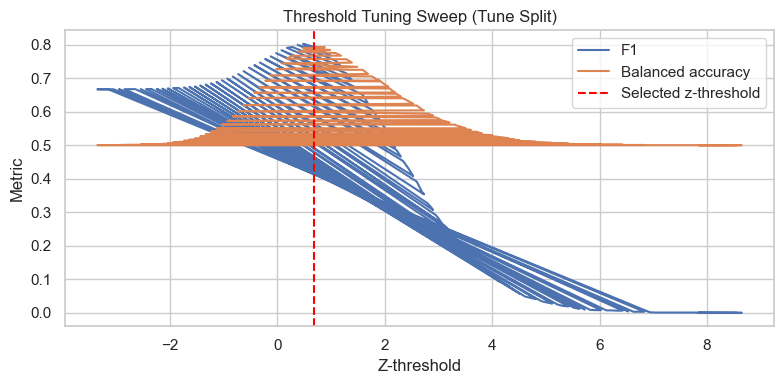

Run the next cell to report final test metrics.


In [10]:
# Load scores and tune threshold on the labeled tune split (test set untouched)
with np.load(os.path.join(ARTIFACT_DIR, 'scores.npz')) as data:
    train_scores_z       = data['train_scores_z']
    tune_normal_scores_z = data['tune_normal_scores_z']
    tune_defect_scores_z = data['tune_defect_scores_z']
    test_normal_scores_z = data['test_normal_scores_z']
    test_defect_scores_z = data['test_defect_scores_z']

y_tune     = np.concatenate([np.zeros(len(tune_normal_scores_z), dtype=int),
                              np.ones(len(tune_defect_scores_z),  dtype=int)])
score_tune = np.concatenate([tune_normal_scores_z, tune_defect_scores_z])

candidate_thresholds = np.unique(
    np.concatenate([
        np.percentile(train_scores_z, np.linspace(95.0, 99.9, 40)),
        np.linspace(score_tune.min(), score_tune.max(), 120),
    ])
)

rows = []
for candidate in candidate_thresholds:
    pred = (score_tune > candidate).astype(int)
    tp = int(((pred == 1) & (y_tune == 1)).sum())
    tn = int(((pred == 0) & (y_tune == 0)).sum())
    fp = int(((pred == 1) & (y_tune == 0)).sum())
    fn = int(((pred == 0) & (y_tune == 1)).sum())

    precision         = tp / (tp + fp) if (tp + fp) else 0.0
    recall            = tp / (tp + fn) if (tp + fn) else 0.0
    f1                = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    specificity       = tn / (tn + fp) if (tn + fp) else 0.0
    balanced_accuracy = 0.5 * (recall + specificity)

    rows.append({
        'threshold_z':       float(candidate),
        'precision':          precision,
        'recall':             recall,
        'f1':                 f1,
        'specificity':        specificity,
        'balanced_accuracy':  balanced_accuracy,
        'fp':                 fp,
        'fn':                 fn,
    })

threshold_tuning = pd.DataFrame(rows).sort_values(
    ['balanced_accuracy', 'f1', 'precision', 'threshold_z'],
    ascending=[False, False, False, True],
).reset_index(drop=True)

best_row      = threshold_tuning.iloc[0]
threshold_z   = float(best_row['threshold_z'])
threshold_raw = train_score_mu + threshold_z * train_score_std

print(f'Tuned z-threshold: {threshold_z:.6f}  (raw: {threshold_raw:.6f})')
print(
    f"Precision={best_row['precision']:.4f} | Recall={best_row['recall']:.4f} | "
    f"F1={best_row['f1']:.4f} | Balanced Acc={best_row['balanced_accuracy']:.4f}"
)
display(threshold_tuning.head(10))

plt.figure(figsize=(8, 4))
plt.plot(threshold_tuning['threshold_z'], threshold_tuning['f1'],               label='F1')
plt.plot(threshold_tuning['threshold_z'], threshold_tuning['balanced_accuracy'], label='Balanced accuracy')
plt.axvline(threshold_z, color='red', linestyle='--', label='Selected z-threshold')
plt.xlabel('Z-threshold')
plt.ylabel('Metric')
plt.title('Threshold Tuning Sweep (Tune Split)')
plt.legend()
plt.tight_layout()
plt.show()
print('Run the next cell to report final test metrics.')

ROC-AUC (z-score): 0.8690
Applied z-threshold: 0.680258 | raw-threshold: 0.773431
              precision    recall  f1-score   support

      normal       0.89      0.78      0.83      5000
     anomaly       0.65      0.81      0.72      2500

    accuracy                           0.79      7500
   macro avg       0.77      0.79      0.77      7500
weighted avg       0.81      0.79      0.79      7500



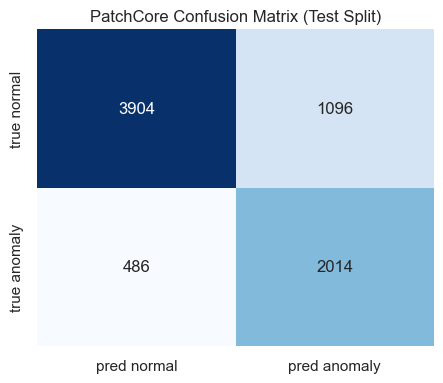

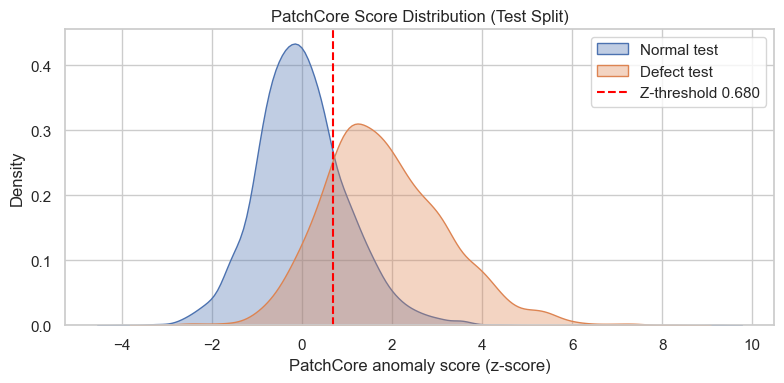

Saved model artifact to: ../artifacts/x64/patchcore_50k\patchcore_model.pt
Saved metrics to: ../artifacts/x64/patchcore_50k\evaluation_metrics.json


In [11]:
# Final evaluation on test split
# threshold_z = 1.2   # uncomment to override the tuned value

y_true = np.concatenate([np.zeros(len(test_normal_scores_z), dtype=int),
                          np.ones(len(test_defect_scores_z),  dtype=int)])
scores = np.concatenate([test_normal_scores_z, test_defect_scores_z])
y_pred = (scores > threshold_z).astype(int)

roc_auc = float(roc_auc_score(y_true, scores))
report  = classification_report(y_true, y_pred, target_names=['normal', 'anomaly'])

print(f'ROC-AUC (z-score): {roc_auc:.4f}')
print(f'Applied z-threshold: {threshold_z:.6f} | raw-threshold: {threshold_raw:.6f}')
print(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred normal', 'pred anomaly'],
            yticklabels=['true normal', 'true anomaly'])
plt.title('PatchCore Confusion Matrix (Test Split)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.kdeplot(test_normal_scores_z, label='Normal test', fill=True, alpha=0.35)
sns.kdeplot(test_defect_scores_z, label='Defect test', fill=True, alpha=0.35)
plt.axvline(threshold_z, color='red', linestyle='--', label=f'Z-threshold {threshold_z:.3f}')
plt.xlabel('PatchCore anomaly score (z-score)')
plt.ylabel('Density')
plt.title('PatchCore Score Distribution (Test Split)')
plt.legend()
plt.tight_layout()
plt.show()

# Store model artifact
artifact = {
    'extractor_state_dict': extractor.state_dict(),
    'pca_components':        pca.components_,
    'pca_mean':              pca.mean_,
    'threshold_z':           float(threshold_z),
    'threshold_raw':         float(threshold_raw),
    'train_score_mu':        float(train_score_mu),
    'train_score_std':       float(train_score_std),
    'config': {
        'image_size':                 IMAGE_SIZE,
        'backbone':                   'wide_resnet50_2',
        'layers':                     'layer2+layer3+layer4',
        'pca_dim':                    PCA_DIM,
        'train_normal_n':             TRAIN_NORMAL_N,
        'tune_normal_n':              TUNE_NORMAL_N,
        'tune_defect_n':              TUNE_DEFECT_N,
        'test_normal_n':              TEST_NORMAL_N,
        'test_defect_n':              TEST_DEFECT_N,
        'memory_bank_max_patches':    MEMORY_BANK_MAX_PATCHES,
        'coreset_candidates':         CORESET_CANDIDATES,
        'score_chunk':                SCORE_CHUNK,
        'patchcore_nn_k':             PATCHCORE_NN_K,
        'patchcore_topk_patch_ratio': PATCHCORE_TOPK_PATCH_RATIO,
    },
}
torch.save(artifact, MODEL_EXPORT_PATH)

metrics = {
    'roc_auc_z':       roc_auc,
    'threshold_z':     float(threshold_z),
    'threshold_raw':   float(threshold_raw),
    'train_score_mu':  float(train_score_mu),
    'train_score_std': float(train_score_std),
    'confusion_matrix': cm.tolist(),
    'n_test_normal':   int(len(test_normal_scores_z)),
    'n_test_defect':   int(len(test_defect_scores_z)),
    'backbone':        'wide_resnet50_2 layer2+3+4',
    'pca_dim':         PCA_DIM,
    'nn_k':            PATCHCORE_NN_K,
    'topk_ratio':      PATCHCORE_TOPK_PATCH_RATIO,
}
pd.Series(metrics).to_json(METRICS_EXPORT_PATH, indent=2)

print('Saved model artifact to:', MODEL_EXPORT_PATH)
print('Saved metrics to:', METRICS_EXPORT_PATH)

In [12]:
# Per-defect-class recall breakdown
tmp = test_defect_df.copy()
tmp['score']    = test_defect_scores_z
tmp['detected'] = (test_defect_scores_z > threshold_z).astype(int)
print('\nPer-defect-class recall:')
display(tmp.groupby('failure_label').agg(
    count     =('detected', 'count'),
    detected  =('detected', 'sum'),
    recall    =('detected', 'mean'),
    mean_score=('score',    'mean'),
).round(3).sort_values('recall'))


Per-defect-class recall:


,count,detected,recall,mean_score
failure_label,,,,
Edge-Loc,471,326,0.692,1.601
Loc,355,257,0.724,1.787
Scratch,127,96,0.756,1.959
Center,419,332,0.792,1.773
Edge-Ring,959,836,0.872,1.732
Donut,64,62,0.969,3.201
Near-full,16,16,1.000,2.701
Random,89,89,1.000,3.016


In [13]:
# Clear memory after run
vars_to_clear = [
    'train_dataset', 'test_normal_dataset', 'test_defect_dataset',
    'sample_x', 'sample_y',
    'sampled_patches', 'candidate_pool', 'candidates_np', 'candidates_pca',
    'memory_bank', 'memory_bank_t', 'pca',
    'train_scores', 'tune_normal_scores', 'tune_defect_scores',
    'test_normal_scores', 'test_defect_scores',
    'train_scores_z', 'tune_normal_scores_z', 'tune_defect_scores_z',
    'test_normal_scores_z', 'test_defect_scores_z',
    'scores', 'y_true', 'y_pred',
    'train_loader', 'tune_normal_loader', 'tune_defect_loader',
    'test_normal_loader', 'test_defect_loader',
]
for name in vars_to_clear:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print('Memory cleared (Python GC + CUDA cache).')

Memory cleared (Python GC + CUDA cache).


## Notes

### Why PCA instead of MiniBatchKMeans coreset?
MiniBatchKMeans on 240k × 3584-dim takes 60-90 min because kNN cost scales as `O(n × d²)`. PCA + random subsample achieves similar representative coverage in ~2-3 minutes:
- PCA(128) on 240k × 3584 → ~2 min (sklearn randomised SVD)
- Random subsample to 50k → instant
- kNN at 128-dim → ~28x faster per query than 3584-dim

### Improvements vs original
| Change | Before | After |
|---|---|---|
| Backbone | ResNet18 | WideResNet-50-2 |
| Layers | layer2+3 (384-dim) | layer2+3+4 (3584→128 PCA) |
| Memory bank | Random sampling | PCA + random subsample |
| nn_k in scorer | Defaulted to 1 | Consistently 3 |
| topk_patch_ratio | 5% | 2% |

### VRAM tips (RTX 4060 8 GB)
- `BATCH_SIZE = 64` is the safe default for WRN50 + AMP at 224×224.
- `SCORE_CHUNK = 2048` is safe at 128-dim; drop to 512 if you hit OOM.

### Tuning levers
- `PCA_DIM` — try 64 for faster scoring or 256 for higher fidelity.
- `TOPK_PATCH_RATIO` — try `0.01` for tight focus or `0.03` if recall drops.
- `PATCHCORE_NN_K` — try 5 for smoother scores.
- `MEMORY_BANK_MAX_PATCHES` — 50k is a good default; 80k may improve coverage.